# Fitting and transferring discrepancy

A discrepancy describes the part of a measured response that a physical model misses. This tutorial fits a lossy coax with a small conductor error, predicts the correction with its uncertainty, and carries it to a new line length. It then shows how a port discrepancy can carry a joint parameter and correction prediction into a terminated circuit.

The [discrepancy prediction example](../examples/discrepancy_prediction.rst) is the short introduction. The code here uses small synthetic data sets so every result can be checked against a known line.

## A reference line and a shorter target

The reference line is 30 cm long; the target is 15 cm. The nominal line has 10% excess conductor loss. A port correction belongs to the reference response, while an internal correction changes characteristic impedance, attenuation, and phase per unit length. That distinction matters when the line length changes.

In [1]:
from pathlib import Path
import sys
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize as scipy_minimize
import pmrf as prf
from pmrf.materials import BulkConductor, ConstantDielectric
from pmrf.models import (
    CoaxialLine, GridLineDiscrepancy, GridPortDiscrepancy, LineCorrected,
    Load, PortCorrected, line_internal_features, project_line_basis_joint,
    reference_line_features,
)
from pmrf.objectives import MarginalLogLikelihood
from pmrf.optimize import ScipyMinimize, minimize
from pmrf.stats import (
    GaussianLikelihood, GaussianProcess, Matern52Kernel, RBFKernel, posterior_covariance,
)

tutorial_dir = Path.cwd()
if not (tutorial_dir / "line_internal_discrepancy.py").exists():
    tutorial_dir = Path("docs/tutorials")
sys.path.insert(0, str(tutorial_dir.resolve()))
from line_internal_discrepancy import (
    MODEL_SIGMA, TRUTH_SIGMA, _basis, compare_transfer,
    exact_values, frequency, line,
)
from port_discrepancy import ReciprocalEventTransform, reciprocal_predictor

f = frequency()
comparison = compare_transfer()
for name, errors in comparison.items():
    print(f"{name}: RMS S21 error = {errors['rms_s21']:.4g}, eta bias = {errors['eta_bias']:.4g}")

uncorrected: RMS S21 error = 0.04652, eta bias = -0.01492
port: RMS S21 error = 0.06091, eta bias = 0.02524
internal: RMS S21 error = 1.404e-16, eta bias = -1.983e-18


The internal correction follows the shorter line's electrical length. The port correction uses the reference line's S-parameter error as if it belonged to the shorter line.

## Learn an internal correction

Here the reference measurement supplies characteristic impedance $Z_c$ and propagation constant $\gamma$. `reference_line_features` converts them to the four log-ratio channels used by `GridLineDiscrepancy`: real and imaginary $\log Z_c$, log attenuation, and log phase constant. The likelihood variance is specified in this transformed event space.

The nominal model has a free conductor parameter. `predict_joint` returns one Gaussian over that parameter and the correction grid, preserving their covariance.

In [2]:
reference = line(0.30, TRUTH_SIGMA)
zc, gamma_length = reference.zc_and_gammaL(f)
observed = reference_line_features(zc, gamma_length / 0.30)
nominal = line(0.30, MODEL_SIGMA, free_sigma=True)
reference_likelihood = MarginalLogLikelihood(
    predictor=line_internal_features,
    observed=observed,
    likelihood=GaussianLikelihood(1e-10),
    discrepancy=GaussianProcess(RBFKernel(0.5) * 0.1**2, jitter=1e-12),
)
names, joint = reference_likelihood.predict_joint(nominal, f, f)
print("Joint dimensions:", joint.mean().shape[0], "parameter names:", names)

Joint dimensions: 29 parameter names: ('conductor.sigma',)


The same prediction can be attached to a shorter line. The joint prior keeps the conductor parameter correlated with the discrepancy values. `truncate='unnormalised'` respects the conductor's validity range for MAP work; it is unsuitable for sampling or evidence calculations.

In [3]:
carrier = GridLineDiscrepancy.from_prediction(f, joint, joint=True)
short_line = LineCorrected(line(0.15, MODEL_SIGMA, free_sigma=True), carrier)
short_line = prf.prior(
    short_line, [*names, "discrepancy.values"], joint,
    truncate="unnormalised",
)
truth_short = line(0.15, TRUTH_SIGMA)
rms_s21 = np.sqrt(np.mean(np.abs(np.asarray(short_line.s(f) - truth_short.s(f))[:, 1, 0])**2))
print("Transferred RMS S21 error:", float(rms_s21))

Transferred RMS S21 error: 9.892791668383594e-08


The joint mean contains the conductor parameter first, then four correction channels. Its diagonal gives marginal uncertainty in each channel; the off-diagonal entries still matter when the correction is used with the conductor parameter.

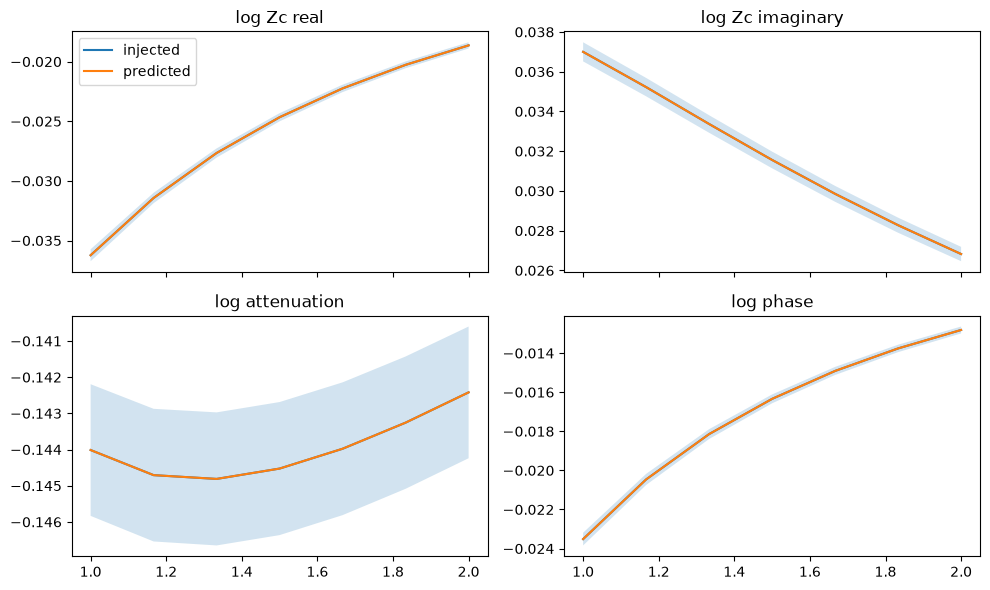

In [4]:
mean = np.asarray(joint.mean())[1:].reshape(2, 2, f.npoints)
std = np.sqrt(np.diag(np.asarray(joint.covariance()))[1:]).reshape(2, 2, f.npoints)
truth = np.asarray(exact_values(f))
labels = ("log Zc real", "log Zc imaginary", "log attenuation", "log phase")
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for axis, label, predicted, sigma, actual in zip(axes.flat, labels, mean.reshape(4, -1), std.reshape(4, -1), truth.reshape(4, -1)):
    axis.plot(f.f_scaled, actual, label="injected")
    axis.plot(f.f_scaled, predicted, label="predicted")
    axis.fill_between(f.f_scaled, predicted - 2*sigma, predicted + 2*sigma, alpha=0.2)
    axis.set_title(label)
axes[0, 0].legend()
fig.tight_layout()

## When only S-parameters are measured

The preceding route uses $Z_c$ and $\gamma$. If the reference only provides complex S-parameters, represent the internal correction with basis coefficients and fit them through the line response. The [supporting script](line_internal_discrepancy.py) defines the basis from an RBF spectral density; the fit and projection are shown below.

In [5]:
basis = _basis(f)
nominal_s = LineCorrected(line(0.30, MODEL_SIGMA), basis)
observed_s = line(0.30, TRUTH_SIGMA).s(f)
s_likelihood = MarginalLogLikelihood(
    predictor=lambda model, grid: model.s(grid),
    observed=observed_s,
    likelihood=GaussianLikelihood(1e-8),
)
objective = lambda model: -s_likelihood(model, f) - prf.log_prior(model)
fitted_s = minimize(objective, nominal_s, solver=ScipyMinimize(method="BFGS"), max_iter=400).model
fitted_basis = prf.update(
    basis, "coefficients", value=prf.values(fitted_s)["discrepancy.coefficients"]
)
linearization = s_likelihood.linearize(fitted_s, f)
covariance = posterior_covariance([linearization], fitted_s)
names_s, joint_s = project_line_basis_joint(
    fitted_s, fitted_basis, linearization, covariance, f
)
carrier_s = GridLineDiscrepancy.from_prediction(f, joint_s, joint=True)
short_s = LineCorrected(line(0.15, MODEL_SIGMA), carrier_s)
rms_s = np.sqrt(np.mean(np.abs(np.asarray(short_s.s(f) - truth_short.s(f))[:, 1, 0])**2))
mean_s = np.asarray(joint_s.mean()).reshape(2, 2, f.npoints)
std_s = np.sqrt(np.diag(np.asarray(joint_s.covariance()))).reshape(2, 2, f.npoints)
coverage = np.mean(np.abs(np.asarray(exact_values(f)) - mean_s) <= 2 * std_s)
print("Transferred RMS S21 error:", float(rms_s))
print("Injected values within mean ± 2σ:", float(coverage))

SciPy BFGS:   0%|          | 0/400 [00:00<?, ?it/s]

Transferred RMS S21 error: 7.115958079928517e-13
Injected values within mean ± 2σ: 1.0


## Port discrepancy in a later circuit

A port correction applies when the fitted component stays the same and its surrounding circuit changes. Here the reference fit estimates a bounded coax length and a reciprocal port discrepancy. The [supporting script](port_discrepancy.py) defines the event transform used for symmetric transmission and contains independent covariance checks. We use that transform below, then carry the joint prediction into a terminated circuit.

In [6]:
def cable(length):
    return CoaxialLine(
        length=length,
        d_in=prf.Fixed(1.12e-3), d_out=prf.Fixed(3.2e-3),
        dielectric=ConstantDielectric(ep_r=prf.Fixed(1.384), tand=prf.Fixed(0.001)),
        conductor=BulkConductor(sigma=prf.Fixed(1 / 1.6e-8)),
    )

reference_f = prf.Frequency(100, 500, 12, "MHz")
transfer_f = prf.Frequency(120, 480, 6, "MHz")
true_cable = cable(prf.Fixed(0.1))
initial_cable = cable(prf.Bounded(0.05, 0.15, value=0.095))
reference_port = MarginalLogLikelihood(
    predictor=reciprocal_predictor,
    observed=reciprocal_predictor(true_cable, reference_f),
    likelihood=GaussianLikelihood(jnp.full((3, 2, reference_f.npoints), 1e-8)),
    discrepancy=GaussianProcess(Matern52Kernel(80.0) * 1e-6, jitter=1e-12),
    event_transform=ReciprocalEventTransform,
)

def port_loss(length):
    return -reference_port(prf.update(initial_cable, {"length": length}), reference_f)

value_gradient = jax.jit(jax.value_and_grad(port_loss))
fit_result = scipy_minimize(
    lambda x: tuple(np.asarray(v) for v in value_gradient(jnp.asarray(x))),
    np.array([0.095]), jac=True, method="L-BFGS-B", bounds=[(0.05, 0.15)],
    options={"maxiter": 1000, "gtol": 1e-10, "ftol": 1e-14},
)
assert fit_result.success
fitted_cable = prf.update(initial_cable, {"length": jnp.asarray(fit_result.x[0])})
port_names, port_joint = reference_port.predict_joint(fitted_cable, reference_f, transfer_f)
print("Fitted length:", float(prf.values(fitted_cable)["length"]))

Fitted length: 0.09999999999999998


In [7]:
port_mean = port_joint.mean()[1:].reshape(3, 2, transfer_f.npoints)
corrected_cable = PortCorrected(
    fitted_cable,
    GridPortDiscrepancy(prf.Unconstrained(port_mean), transfer_f, ("11", "22", "s21")),
)
corrected_cable = prf.prior(
    corrected_cable, [*port_names, "discrepancy.values"], port_joint,
    truncate="unnormalised",
)
load = Load(gamma=(75.0 - 50.0) / (75.0 + 50.0), z0=50.0)
transfer_circuit = corrected_cable.terminated(load)
observed_reflection = true_cable.terminated(load).s(transfer_f, z0=50.0)[:, 0, 0]
transfer_likelihood = MarginalLogLikelihood(
    predictor=lambda model, grid: model.s(grid, z0=50.0)[:, 0, 0],
    observed=observed_reflection,
    likelihood=GaussianLikelihood(1e-6),
)
transfer_linearization = transfer_likelihood.linearize(
    transfer_circuit, transfer_f, space="declared"
)
transfer_covariance = posterior_covariance(
    [transfer_linearization], transfer_circuit, space="declared"
)
print("Joint dimension:", port_joint.mean().shape[0])
print("Transferred log prior:", float(prf.log_prior(transfer_circuit, space="declared")))
print("Posterior variance, first coordinate:", float(transfer_covariance[0, 0]))

Joint dimension: 37


Transferred log prior: 305.72558741009493
Posterior variance, first coordinate: 4.566409745486896e-09


The carrier follows what stays physically common between fits: use an internal line correction across lengths, or a port correction when moving the same component into another circuit. The joint distribution retains parameter–discrepancy covariance in each later calculation. The [port script](port_discrepancy.py) compares the final covariance with a NumPy Kalman update and checks the transferred prior's precision.